Importing All the Packages

In [65]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (classification_report,confusion_matrix,ConfusionMatrixDisplay,accuracy_score)

Parsing the Data into a Dataframe

In [66]:
df = pd.read_csv("data.csv")
pd.set_option('display.max_columns', None) #for displaying all columns
pd.set_option('display.max_rows', None)    #for displaying all rows
df.head(10)

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,1.256969e-04,0.0,0.458143,0.000725,0.000000,0.147950,0.147950,0.147950,0.169141,0.311664,0.017560,0.095921,0.138736,0.022102,0.848195,0.688979,0.688979,0.217535,4.980000e+09,0.000327,0.263100,0.363725,0.002259,0.001208,0.629951,0.021266,0.207576,0.792424,0.005024,0.390284,0.006479,0.095885,0.137757,0.398036,0.086957,0.001814,0.003487,1.820926e-04,1.165007e-04,0.032903,0.034164,0.392913,0.037135,0.672775,0.166673,0.190643,0.004094,0.001997,1.473360e-04,0.147308,0.334015,0.276920,0.001036,0.676269,0.721275,0.339077,0.025592,0.903225,0.002022,0.064856,7.010000e+08,6.550000e+09,0.593831,4.580000e+08,0.671568,0.424206,0.676269,0.339077,0.126549,0.637555,0.458609,0.520382,0.312905,0.118250,0,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,2.897851e-04,0.0,0.461867,0.000647,0.000000,0.182251,0.182251,0.182251,0.208944,0.318137,0.021144,0.093722,0.169918,0.022080,0.848088,0.689693,0.689702,0.217620,6.110000e+09,0.000443,0.264516,0.376709,0.006016,0.004039,0.635172,0.012502,0.171176,0.828824,0.005059,0.376760,0.005835,0.093743,0.168962,0.397725,0.064468,0.001286,0.004917,9.360000e+09,7.190000e+08,0.025

In [67]:
df.shape

(6819, 96)

In [68]:
df.columns

Index(['Bankrupt?', ' ROA(C) before interest and depreciation before interest',
       ' ROA(A) before interest and % after tax',
       ' ROA(B) before interest and depreciation after tax',
       ' Operating Gross Margin', ' Realized Sales Gross Margin',
       ' Operating Profit Rate', ' Pre-tax net Interest Rate',
       ' After-tax net Interest Rate',
       ' Non-industry income and expenditure/revenue',
       ' Continuous interest rate (after tax)', ' Operating Expense Rate',
       ' Research and development expense rate', ' Cash flow rate',
       ' Interest-bearing debt interest rate', ' Tax rate (A)',
       ' Net Value Per Share (B)', ' Net Value Per Share (A)',
       ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons',
       ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)',
       ' Operating Profit Per Share (Yuan ¥)',
       ' Per Share Net profit before tax (Yuan ¥)',
       ' Realized Sales Gross Profit Growth Rate',
       ' Operating Profit

In [69]:
df.columns = df.columns.str.strip() # for cleaning accidental spaces in column names

In [70]:
df.info() # to check the data types of each column

<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2   ROA(A) before interest and % after tax                   6819 non-null   float64
 3   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4   Operating Gross Margin                                   6819 non-null   float64
 5   Realized Sales Gross Margin                              6819 non-null   float64
 6   Operating Profit Rate                                    6819 non-null   float64
 7   Pre-tax net Interest Rate                                6819 non-null   float64
 8   After-tax net Interest Rate            

In [71]:
df.isnull().sum() # to check for missing values in each column

Bankrupt?                                                  0
ROA(C) before interest and depreciation before interest    0
ROA(A) before interest and % after tax                     0
ROA(B) before interest and depreciation after tax          0
Operating Gross Margin                                     0
Realized Sales Gross Margin                                0
Operating Profit Rate                                      0
Pre-tax net Interest Rate                                  0
After-tax net Interest Rate                                0
Non-industry income and expenditure/revenue                0
Continuous interest rate (after tax)                       0
Operating Expense Rate                                     0
Research and development expense rate                      0
Cash flow rate                                             0
Interest-bearing debt interest rate                        0
Tax rate (A)                                               0
Net Value Per Share (B) 

In [72]:
df.duplicated().sum() # to check for duplicate rows in the dataset

np.int64(0)

Checking and Analysing the Target Variable

In [73]:
df["Bankrupt?"].value_counts() # to check the distribution of the target variable

Bankrupt?
0    6599
1     220
Name: count, dtype: int64

In [ ]:
df["Bankrupt?"].value_counts(normalize=True) * 100  # key insight : about 3 percent is bankrupt and 97 percent is not bankrupt.The dataset is highly imbalanced.

Bankrupt?
0    96.77372
1     3.22628
Name: proportion, dtype: float64

Analysing the Features

In [75]:
df.describe() #descriptive summary of the features

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6.819000e+03,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6819.000000,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6.819000e+03,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,0.781381,1.995347e+09,1.950427e+09,0.467431,1.644801e+07,0.11

In [76]:
correlation_features = correlations = df.corr(numeric_only=True)["Bankrupt?"].sort_values()

In [77]:
correlation_features

Net Income to Total Assets                                -0.315457
ROA(A) before interest and % after tax                    -0.282941
ROA(B) before interest and depreciation after tax         -0.273051
ROA(C) before interest and depreciation before interest   -0.260807
Net worth/Assets                                          -0.250161
Persistent EPS in the Last Four Seasons                   -0.219560
Retained Earnings to Total Assets                         -0.217779
Net profit before tax/Paid-in capital                     -0.207857
Per Share Net profit before tax (Yuan ¥)                  -0.201395
Working Capital to Total Assets                           -0.193083
Net Income to Stockholder's Equity                        -0.180987
Net Value Per Share (A)                                   -0.165465
Net Value Per Share (B)                                   -0.165399
Net Value Per Share (C)                                   -0.164784
Working Capital/Equity                          

In [78]:
correlation_features.head(10) # top 10 features with negative correlation with the target variable
#Higher value suggests lower bankruptcy risk as these values are negatively correlated.

Net Income to Total Assets                                -0.315457
ROA(A) before interest and % after tax                    -0.282941
ROA(B) before interest and depreciation after tax         -0.273051
ROA(C) before interest and depreciation before interest   -0.260807
Net worth/Assets                                          -0.250161
Persistent EPS in the Last Four Seasons                   -0.219560
Retained Earnings to Total Assets                         -0.217779
Net profit before tax/Paid-in capital                     -0.207857
Per Share Net profit before tax (Yuan ¥)                  -0.201395
Working Capital to Total Assets                           -0.193083
Name: Bankrupt?, dtype: float64

In [79]:
correlation_features.tail(10) # top 10 features with positive correlation with the target variable
#Higher value suggests higher bankruptcy risk as these values are positively correlated.

Liability-Assets Flag                  0.139212
Current Liability to Equity            0.153828
Current Liabilities/Equity             0.153828
Liability to Equity                    0.166812
Current Liability to Current Assets    0.171306
Borrowing dependency                   0.176543
Current Liability to Assets            0.194494
Debt ratio %                           0.250161
Bankrupt?                              1.000000
Net Income Flag                             NaN
Name: Bankrupt?, dtype: float64

Visualising few features/variables for further insights

In [80]:
# top 5 features with highest correlation with target variable
top_features = (
    df.corr(numeric_only=True)["Bankrupt?"]
      .abs()
      .sort_values(ascending=False)
      .iloc[1:6]
      .index
)

top_features

Index(['Net Income to Total Assets', 'ROA(A) before interest and % after tax',
       'ROA(B) before interest and depreciation after tax',
       'ROA(C) before interest and depreciation before interest',
       'Net worth/Assets'],
      dtype='str')

Visulaising top 5 correlated variables with the target variable 

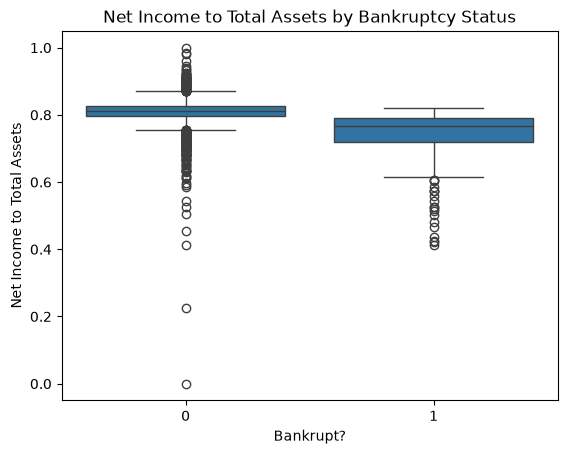

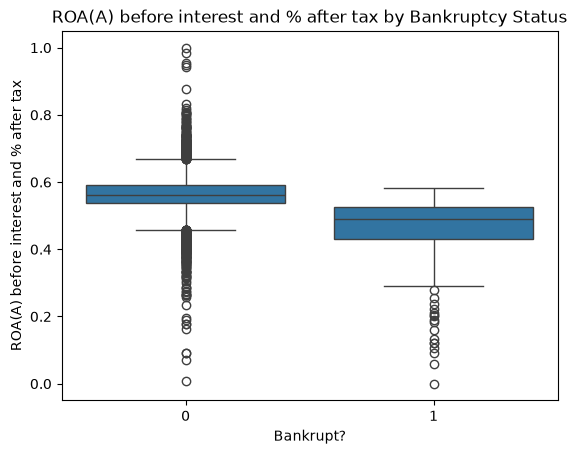

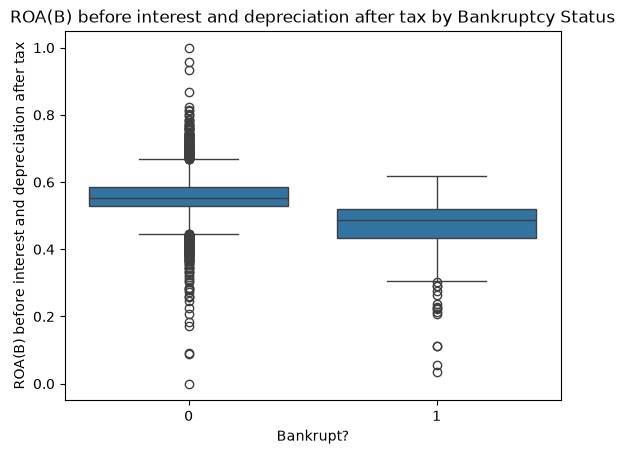

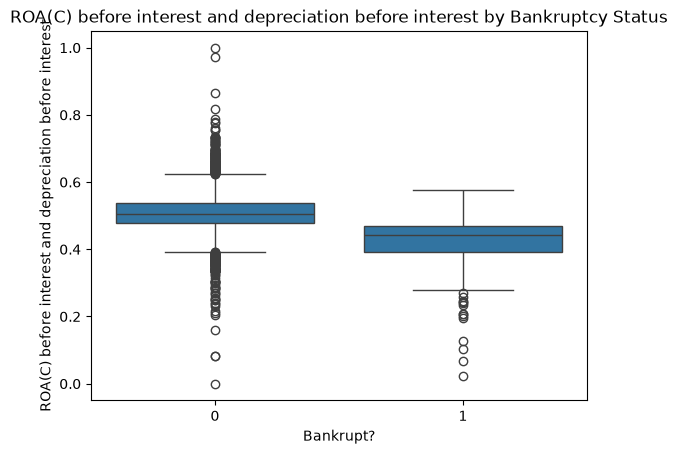

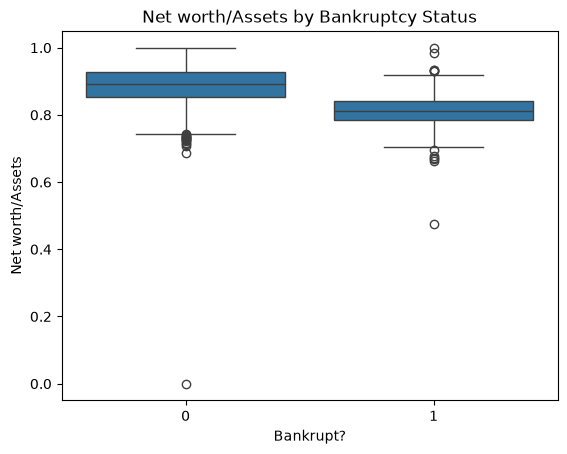

In [81]:
#running a for loop to access every feature in the top feature list and plotting a boxplot for each one against the target variable "Bankrupt?"

for items in range(len(top_features)):
    feature = top_features[items]

    sns.boxplot(
        x="Bankrupt?",
        y=feature,
        data=df)

    plt.title(f"{feature} by Bankruptcy Status")
    plt.show()

 

Machine Learning Model Training

In [82]:
X = df.drop("Bankrupt?", axis=1)

y = df["Bankrupt?"]

In [83]:
# Splitting the dataset into training and testing parts 
# random state makes the split reproducable
# statify=y ensures that the distribution of the target variable is similar in both training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Logistic Regression

In [84]:
#using standard scaler to scale the features and logistic regression as the model for prediction. Using a pipeline to combine both steps.
# class weight = balanced is used to handle the class imbalance in the dataset. It assigns weights to the classes inversely proportional to their frequencies, giving more importance to the minority class (bad credit risk) during model training.
#  This helps improve the model's ability to correctly classify instances of the minority class, leading to better overall performance on imbalanced datasets.    
model = Pipeline([
    ("scaler", StandardScaler()),
    
    ("logistic_regression", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

In [85]:
#training the model using the training data
model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('logistic_regression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [86]:
y_pred = model.predict(X_test)

Results

In [87]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 87.83%


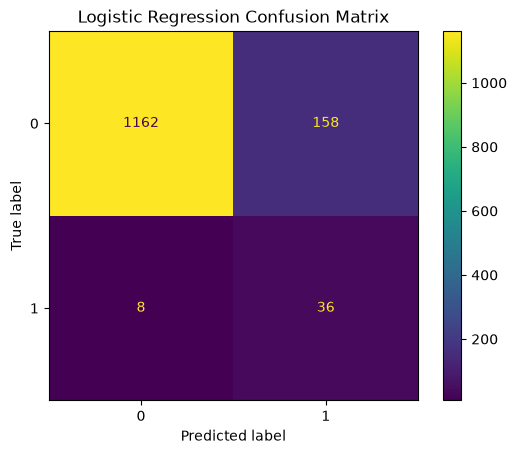

In [88]:
#confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

Classification Report

In [89]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.88      0.93      1320
           1       0.19      0.82      0.30        44

    accuracy                           0.88      1364
   macro avg       0.59      0.85      0.62      1364
weighted avg       0.97      0.88      0.91      1364



Insights on which features contributed the most in Logistic Regression

In [90]:
log_model = model.named_steps["logistic_regression"]

In [91]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

In [ ]:
#absolute value of the coefficients is calculated to identify the features with the highest impact on the model's predictions.
coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient,Absolute_Coefficient
18,Persistent EPS in the Last Four Seasons,-2.307697,2.307697
94,Equity to Liability,-1.849158,1.849158
90,Liability to Equity,-1.780111,1.780111
32,Current Ratio,-1.756276,1.756276
39,Borrowing dependency,1.647783,1.647783
45,Accounts Receivable Turnover,-1.300924,1.300924
85,Net Income to Total Assets,-1.295668,1.295668
15,Net Value Per Share (B),-1.111402,1.111402
35,Total debt/Total net worth,1.056837,1.056837
1,ROA(A) before interest and % after tax,0.905402,0.905402


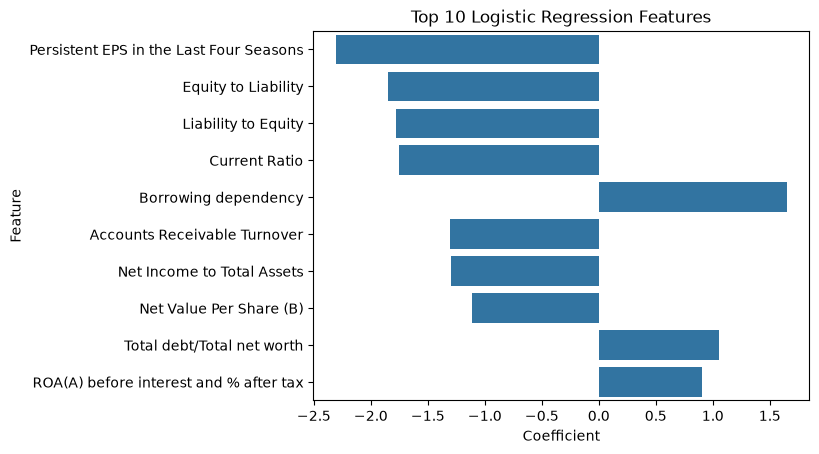

In [ ]:
#plotting the top 10 features with the highest absolute coefficients from the logistic regression model. 
# These features have the most significant impact on predicting bankruptcy risk.
top10 = coefficients.head(10)

sns.barplot(
    data=top10,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Logistic Regression Features")
plt.show()

Random Forest

In [ ]:
#n_estimators=200 means that the random forest model will create 200 decision trees during training.
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

random_forest.fit(X_train, y_train)

random_forest_pred = random_forest.predict(X_test)



Results

In [95]:
accuracy = accuracy_score(y_test, random_forest_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 97.21%


In [96]:
print(classification_report(y_test,random_forest_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1320
           1       0.80      0.18      0.30        44

    accuracy                           0.97      1364
   macro avg       0.89      0.59      0.64      1364
weighted avg       0.97      0.97      0.96      1364



Insights on which features contributed the most
in Random Forest 

In [97]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

In [98]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance.head(10)

,Feature,Importance
39,Borrowing dependency,0.049484
85,Net Income to Total Assets,0.045324
35,Total debt/Total net worth,0.044701
18,Persistent EPS in the Last Four Seasons,0.043608
94,Equity to Liability,0.032958
68,Total income/Total expense,0.029404
67,Retained Earnings to Total Assets,0.028424
37,Net worth/Assets,0.028323
42,Net profit before tax/Paid-in capital,0.028189
9,Continuous interest rate (after tax),0.027856


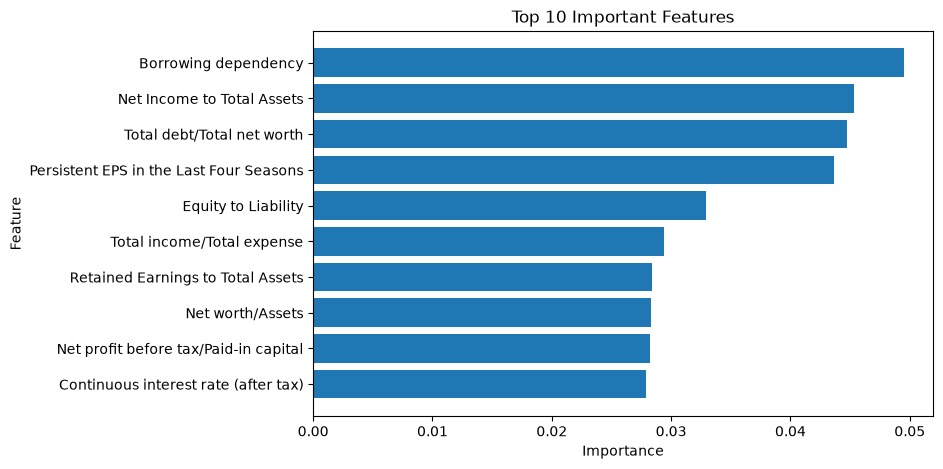

In [ ]:
# top features with the highest importance scores from the random forest model.
top_features = importance.head(10)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()